# Notebook central

Esse é o notebook que orquestra toda a análise do projeto CEA - 26P19



In [1]:
# Fazer instalações necessárias
%pip install -r requirements.txt

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [6]:
# Importar bibliotecas e arquivos necessários para a análise
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Adicionar pasta do projeto ao path
project_path = os.getcwd()
if project_path not in sys.path:
    sys.path.insert(0, project_path)

# Imports das funções e configurações 
# (reload garante versão atualizada dos módulos)
import importlib
import funcoes.funcoes1
import config
importlib.reload(funcoes.funcoes1)
importlib.reload(config)

from config import PipelineConfig, DEFAULT_CONFIG
import funcoes.funcoes1 as f1

# Configuração
cfg = DEFAULT_CONFIG



In [14]:
# Lê o arquivo com os dados, calcula e exibe o uso de memória (em MB) de cada base 
# de dados (aba) contida no dicionário, além de apresentar o consumo total ao final.

data = pd.read_excel(cfg.data_file, sheet_name= None)
f1.memory_by_df(data_dict= data)

Uso de memória por aba:
 - completo_com_zeros: 13.06 MB
 - resultados_swan: 13.27 MB

Tamanho Total dos dados: 26.33 MB


In [15]:
raw_data = data[cfg.sheet_raw_data].copy()

# Criando uma coluna datetime e coluna de data no formato YYYYmmdd
raw_data["data"] = pd.to_datetime({
    "year": raw_data[cfg.year],
    "month": raw_data[cfg.month],
    "day": raw_data[cfg.day],
    "hour": raw_data[cfg.hour],
    "minute": raw_data[cfg.minute]
})
raw_data["data_simplificada"] = raw_data["data"].dt.strftime("%Y%m%d").astype(int)

# Tradizindo a direção do vento
raw_data = f1.compass_rose_map(data= raw_data, direction_column= cfg.direction_column)

raw_data.head()

c:\Users\luhan\OneDrive\CEA\CEA II\Códigos\funcoes\funcoes1.py:121: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['SE -> NW' 'SE -> NW' 'SE -> NW' ... 'E -> W' 'E -> W' 'E -> W']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data_copy.loc[mascara_validos, "Dir-vento-map"] = direcoes[indices]


,ano,mes,dia,hora,minuto,Vel-vento,Dir-vento,h2(f)=10,h2(f)=20,h2(f)=30,data,data_simplificada,Dir-vento-map
0,2010,10,22,20,0,5.024,134.296,NaN,NaN,0.083546,2010-10-22 20:00:00,20101022,SE -> NW
1,2010,10,22,20,1,5.024,134.296,NaN,NaN,0.087826,2010-10-22 20:01:00,20101022,SE -> NW
2,2010,10,22,20,2,5.024,134.296,NaN,NaN,0.058701,2010-10-22 20:02:00,20101022,SE -> NW
3,2010,10,22,20,3,5.024,134.296,NaN,NaN,0.067777,2010-10-22 20:03:00,20101022,SE -> NW
4,2010,10,22,20,4,5.024,134.296,NaN,NaN,0.067384,2010-10-22 20:04:00,20101022,SE -> NW


In [5]:
raw_data.dtypes

ano                           int64
mes                           int64
dia                           int64
hora                          int64
minuto                        int64
Vel-vento                   float64
Dir-vento                   float64
h2(f)=10                    float64
h2(f)=20                    float64
h2(f)=30                    float64
data                 datetime64[ns]
data_simplificada             int64
Dir-vento-map                object
dtype: object

# Análise descritiva

## Análise de dados faltantes

In [16]:
# Agrupando e contando nulos e não nulos
null_velo_summary = (
    raw_data[["data_simplificada", cfg.speed_column]]
    .groupby("data_simplificada")[cfg.speed_column]
    .agg(
        nao_nulos= "count",
        nulos= lambda x: x.isna().sum(),
        total= "size"
    ))
# Printando o resumo dos dados
print(f"  - Descritivo de nulos para a coluna '{cfg.speed_column}' \n")
print(null_velo_summary[null_velo_summary["nulos"] > 0])


# Agrupando e contando nulos e não nulos
null_dir_summary = (
    raw_data[["data_simplificada", cfg.direction_column]]
    .groupby("data_simplificada")[cfg.direction_column]
    .agg(
        nao_nulos= "count",
        nulos= lambda x: x.isna().sum(),
        total= "size"
    ))
# Printando o resumo dos dados
print()
print("="*60)
print(f"  - Descritivo de nulos para a coluna '{cfg.direction_column}' \n")
print(null_dir_summary[null_dir_summary["nulos"] > 0])


# Agrupando e contando nulos e não nulos
null_h2_summary = (
    raw_data[["data_simplificada", cfg.target_column]]
    .groupby("data_simplificada")[cfg.target_column]
    .agg(
        nao_nulos= "count",
        nulos= lambda x: x.isna().sum(),
        total= "size"
    ))
# Printando o resumo dos dados
print()
print("="*60)
print(f"  - Descritivo de nulos para a coluna '{cfg.target_column}' \n")
print(null_h2_summary[null_h2_summary["nulos"] > 0])

  - Descritivo de nulos para a coluna 'Vel-vento' 

                   nao_nulos  nulos  total
data_simplificada                         
20101101                1380     60   1440
20101130                 841    599   1440
20110117                1320    120   1440
20110118                 960    480   1440

  - Descritivo de nulos para a coluna 'Dir-vento' 

                   nao_nulos  nulos  total
data_simplificada                         
20101101                1380     60   1440
20101130                 841    599   1440
20110117                1320    120   1440
20110118                 960    480   1440

  - Descritivo de nulos para a coluna 'h2(f)=30' 

                   nao_nulos  nulos  total
data_simplificada                         
20110117                1320    120   1440
20110118                 997    443   1440


In [17]:
# Cria uma condição de nulos para cada coluna
nulo_vel = raw_data[cfg.speed_column].isna()
nulo_dir = raw_data[cfg.direction_column].isna()
nulo_h2 = raw_data[cfg.target_column].isna()

# Verifica se a condição de nulo é idêntica entre as três
mesmas_linhas = "Sim" if (nulo_vel == nulo_dir).all() else "Não"

# Se retornar True, significa que os nulos andam 100% juntos
print(f"Os nulos estão exatamente nas mesmas linhas de velocidades?\n - {mesmas_linhas}")

Os nulos estão exatamente nas mesmas linhas de velocidades?
 - Sim


In [18]:
raw_data["data_simplificada"].nunique()

120

## Variabilidade das colunas

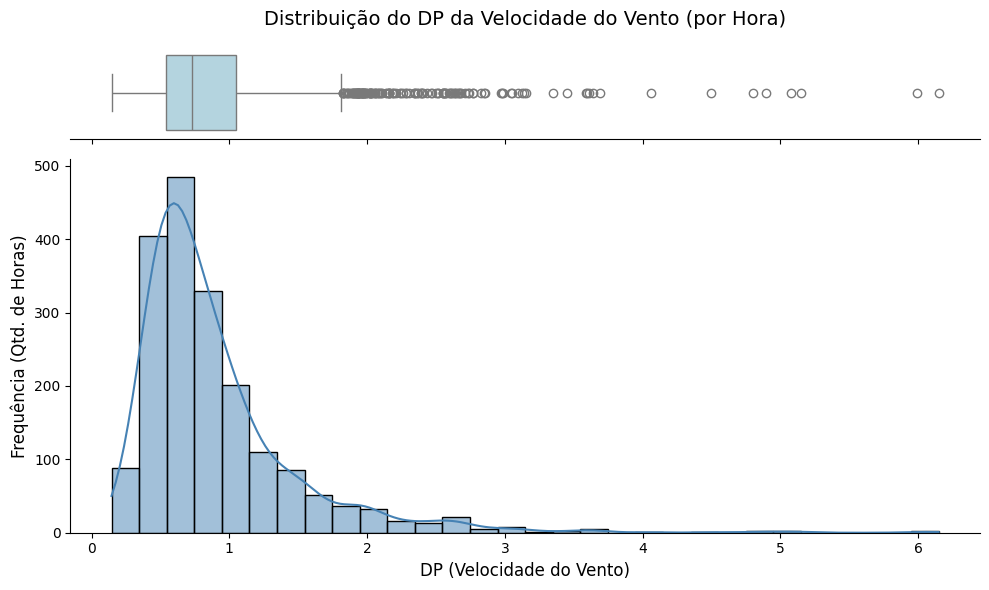

In [19]:
# 1. Agrupamento e cálculo da variância
# Usamos reset_index para transformar o resultado de volta em um DataFrame com colunas normais
df_variancia = (
    raw_data[raw_data["data_simplificada"] > 20101202]
    .groupby(["data_simplificada", "hora"])["Vel-vento"]
    .std()
    .reset_index(name= "dp_vel_vento")
)

# É importante remover valores nulos. 
# Se uma determinada hora tiver apenas 1 registro válido, a variância será NaN (pois variância exige pelo menos 2 pontos)
df_variancia = df_variancia.dropna(subset= ["dp_vel_vento"])


# 2. Configuração do Gráfico (Boxplot em cima, Histograma embaixo)
# gridspec_kw define a proporção de altura (20% para o boxplot, 80% para o histograma)
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [0.2, 0.8]})

# --- Plotando o Boxplot (Eixo Superior) ---
sns.boxplot(x=df_variancia["dp_vel_vento"], ax=ax_box, color="lightblue")
ax_box.set(xlabel="") # Remove o nome do eixo X para não ficar repetitivo
ax_box.set_yticks([]) # Oculta os marcadores do eixo Y do boxplot (não são necessários)
ax_box.set_title("Distribuição do DP da Velocidade do Vento (por Hora)", fontsize=14, pad=15)

# --- Plotando o Histograma (Eixo Inferior) ---
# kde=True adiciona a linha de tendência (curva de densidade)
sns.histplot(data=df_variancia, x="dp_vel_vento", bins=30, kde=True, ax=ax_hist, color="steelblue")
ax_hist.set_xlabel("DP (Velocidade do Vento)", fontsize=12)
ax_hist.set_ylabel("Frequência (Qtd. de Horas)", fontsize=12)

# Limpando as bordas do gráfico para um visual mais limpo (opcional, mas recomendado)
sns.despine(ax=ax_box, left=True)
sns.despine(ax=ax_hist)

# Ajusta o layout para evitar sobreposição
plt.tight_layout()

# Exibe o gráfico
plt.show()

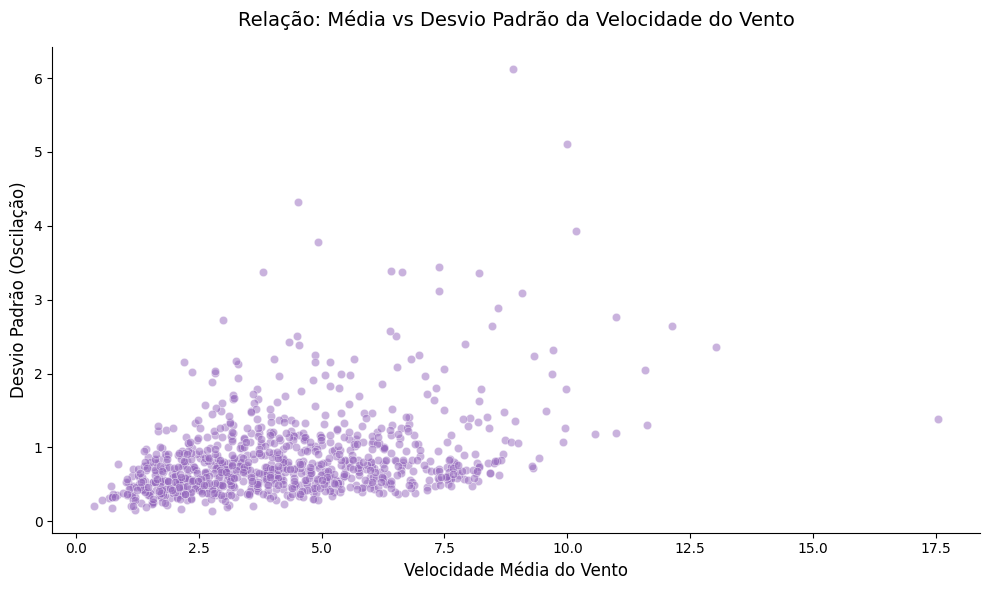

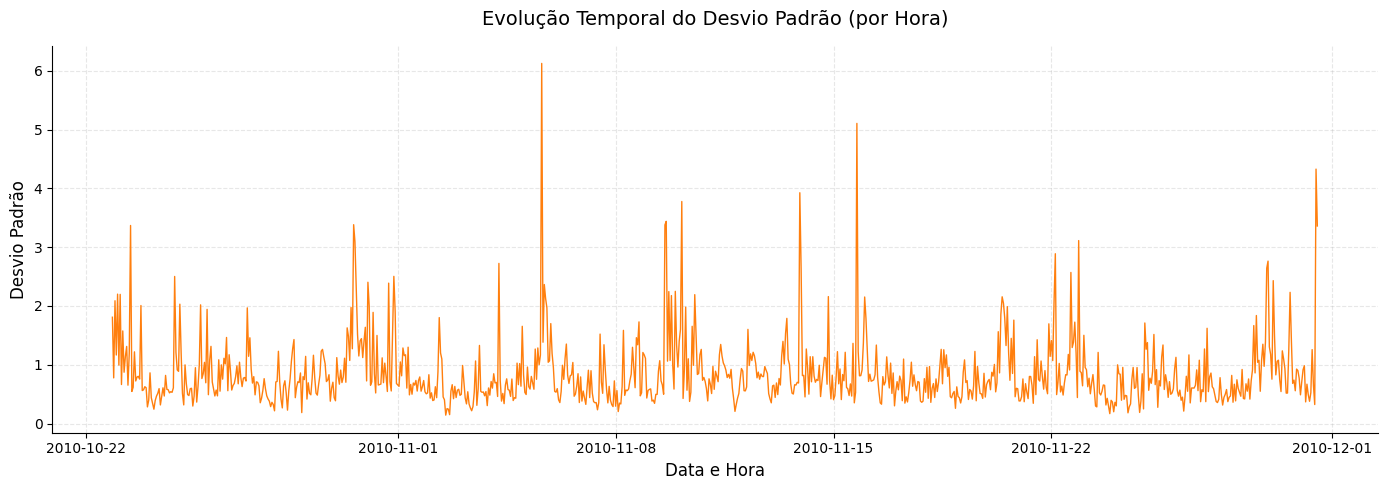

In [21]:
# --- PARTE 1: Preparação dos Dados ---
# Agrupamos por dia e hora, calculando a Média e o Desvio Padrão (std)
df_stats = raw_data[raw_data["data_simplificada"] < 20101223].groupby(['data_simplificada', 'hora'])['Vel-vento'].agg(
    media_vel='mean',
    dp_vel='std'
).reset_index()

# Removemos linhas onde o DP é nulo (ex: horas com apenas 1 minuto de registro válido)
df_stats = df_stats.dropna(subset=['dp_vel'])

# Criamos uma coluna 'data_hora' real para o gráfico de linha não ter saltos temporais
# Transformamos os números em texto para concatenar e depois converter para datetime
df_stats['data_hora'] = pd.to_datetime(
    df_stats['data_simplificada'].astype(str) + ' ' + df_stats['hora'].astype(str),
    format='%Y%m%d %H'
)


# --- PARTE 2: Gráfico de Dispersão (Média vs Desvio Padrão) ---
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=df_stats, x='media_vel', y='dp_vel', alpha=0.5, color='tab:purple', ax=ax1)
ax1.set_title('Relação: Média vs Desvio Padrão da Velocidade do Vento', fontsize=14, pad=15)
ax1.set_xlabel('Velocidade Média do Vento', fontsize=12)
ax1.set_ylabel('Desvio Padrão (Oscilação)', fontsize=12)

sns.despine(ax=ax1)
plt.tight_layout()
plt.show()


# --- PARTE 3: Gráfico Temporal em Linha (Desvio Padrão ao longo do tempo) ---
fig, ax2 = plt.subplots(figsize=(14, 5))

# Usamos a coluna 'data_hora' no eixo X para garantir a continuidade perfeita do tempo
ax2.plot(df_stats['data_hora'], df_stats['dp_vel'], color='tab:orange', linewidth=1)
ax2.set_title('Evolução Temporal do Desvio Padrão (por Hora)', fontsize=14, pad=15)
ax2.set_xlabel('Data e Hora', fontsize=12)
ax2.set_ylabel('Desvio Padrão', fontsize=12)
ax2.grid(True, alpha=0.3, linestyle='--')

sns.despine(ax=ax2)
plt.tight_layout()
plt.show()

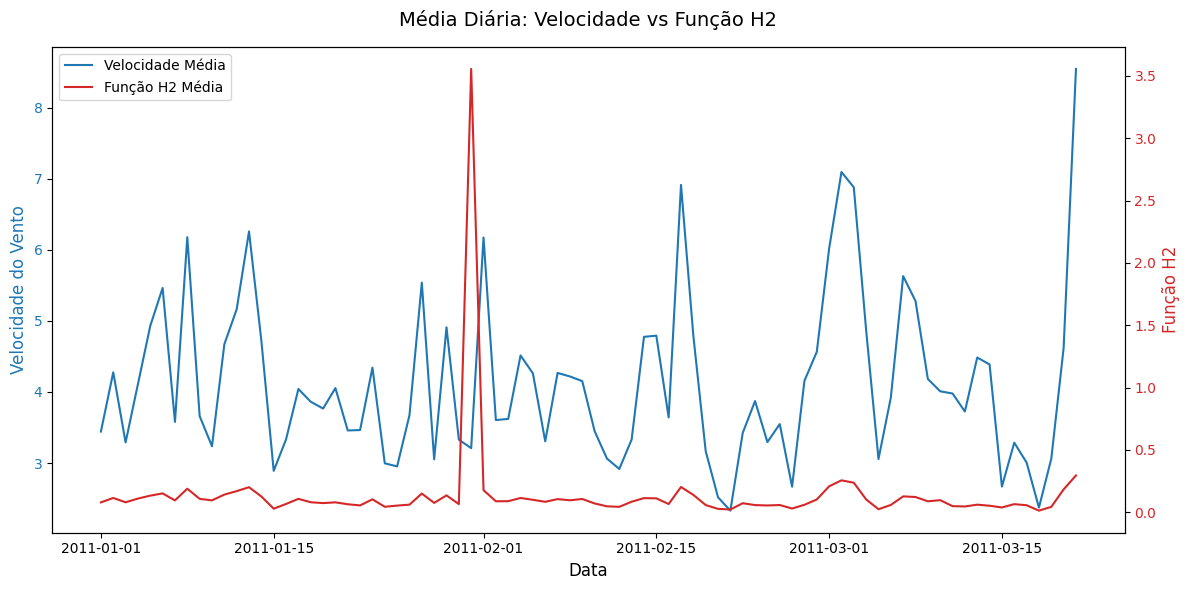

In [9]:
# Analisando comportamento temporal
agruped_df = (
    raw_data[raw_data["data_simplificada"].between(20101231, 20111231)]
    .groupby("data_simplificada")[[cfg.speed_column, cfg.target_column]]
    .mean()
)
agruped_df.index = pd.to_datetime(agruped_df.index, format= "%Y%m%d")

# Criando a figura
fig, ax1 = plt.subplots(figsize= (12, 6))

cor_vel = "tab:blue"
ax1.set_xlabel("Data", fontsize= 12)
ax1.set_ylabel("Velocidade do Vento", color= cor_vel, fontsize= 12)

linha1 = ax1.plot(agruped_df.index, agruped_df[cfg.speed_column], color=cor_vel, label="Velocidade Média")
ax1.tick_params(axis="y", labelcolor=cor_vel)


ax2 = ax1.twinx()  

cor_dir = "tab:red"
ax2.set_ylabel("Função H2", color=cor_dir, fontsize=12)

linha2 = ax2.plot(agruped_df.index, agruped_df[cfg.target_column], color=cor_dir, label="Função H2 Média")
ax2.tick_params(axis="y", labelcolor=cor_dir)

# --- Ajustes finais (Título e Legendas) ---
plt.title("Média Diária: Velocidade vs Função H2", fontsize=14, pad=15)

linhas = linha1 + linha2
labels = [l.get_label() for l in linhas]
ax1.legend(linhas, labels, loc="upper left")

fig.tight_layout() 
plt.show()

In [6]:
# EXEMPLO DE USO:
final_raw_data = f1.imputador_interativo_larrubia(
    raw_data, 
    col_alvo= cfg.speed_column, 
    gap_teste= 600, 
    period= 1440,
    grau_pol= 5
)


--- Iniciando Avaliação para a coluna: Vel-vento ---
Aplicando Metodo 1 (Regressão + Resíduos)...
Aplicando Metodo 2 (Decomposição Clássica)...
Aplicando Metodo 3 (Decomposição STL)...

=== RELATÓRIO DE MÉTRICAS ===
[1] Regressao + Residuos:
    RMSE: 1.3479 | MAE: 1.1612 | MAPE: 56.11%
[2] Decomposicao Classica:
    RMSE: 1.3053 | MAE: 1.0400 | MAPE: 70.90%
[3] STL:
    RMSE: 3.2231 | MAE: 2.6614 | MAPE: 181.53%

Processando do Método 1 imputação na base completa...
Os dados preenchidos estão na nova coluna: 'Vel-vento_filled'.


Foram encontradas 4 lacunas isoladas na série.


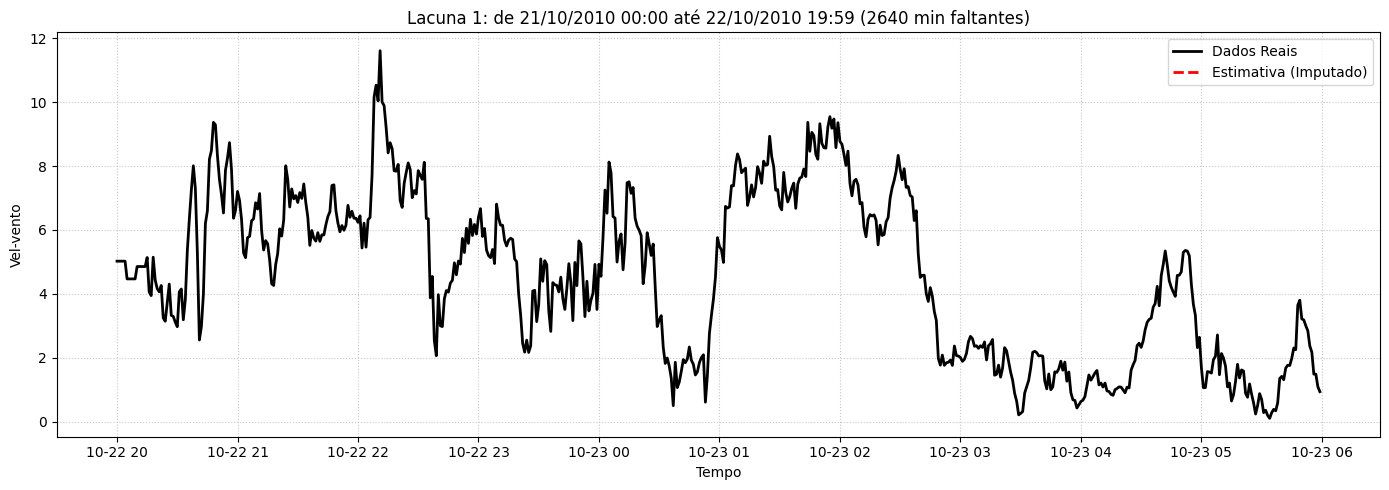

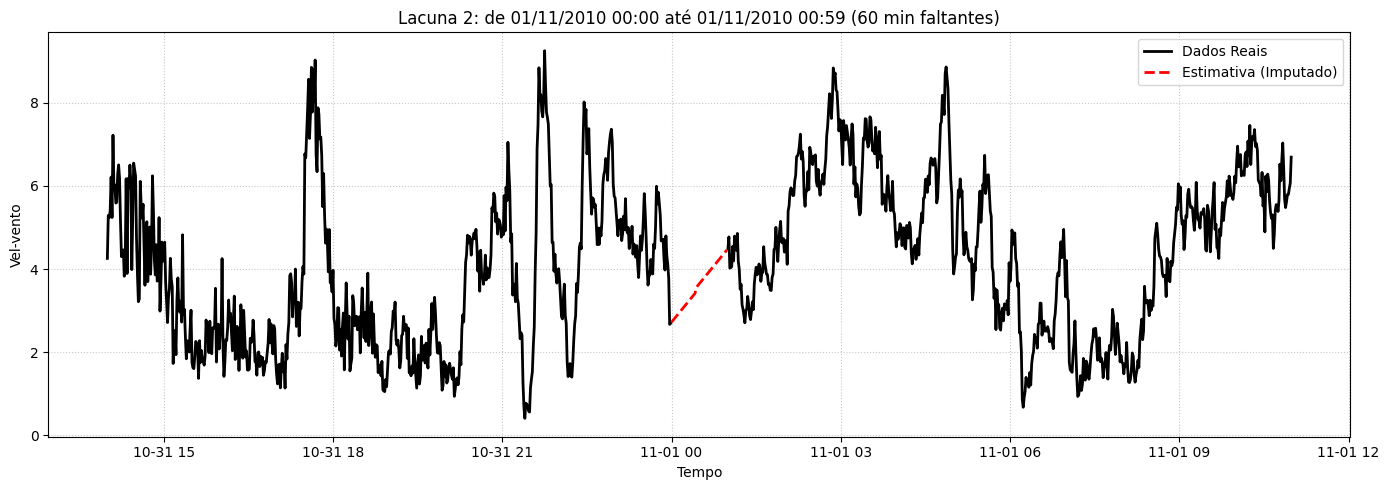

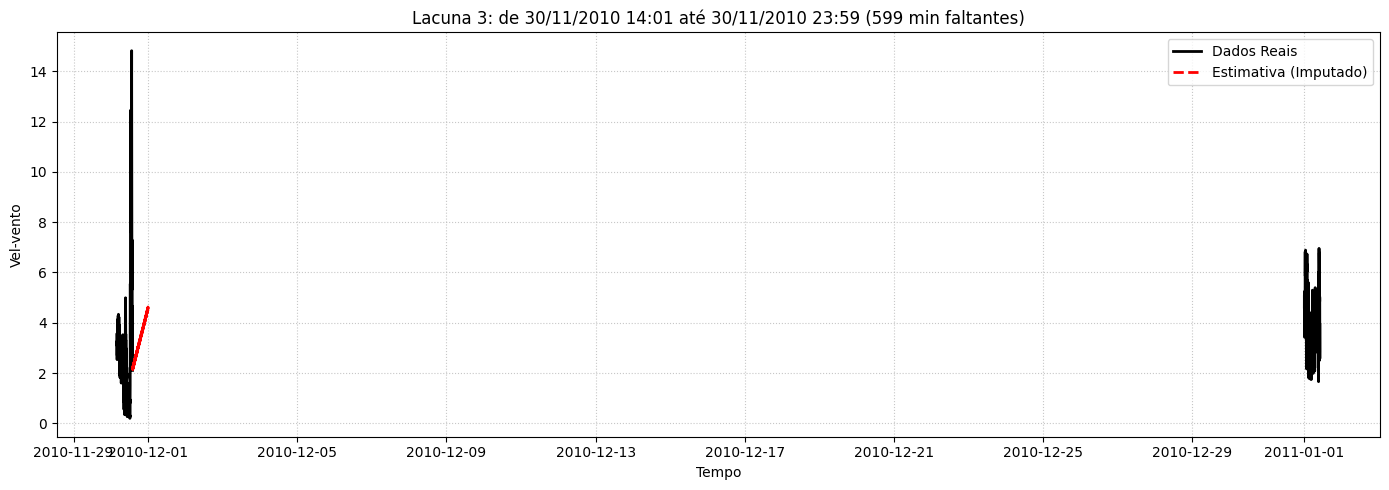

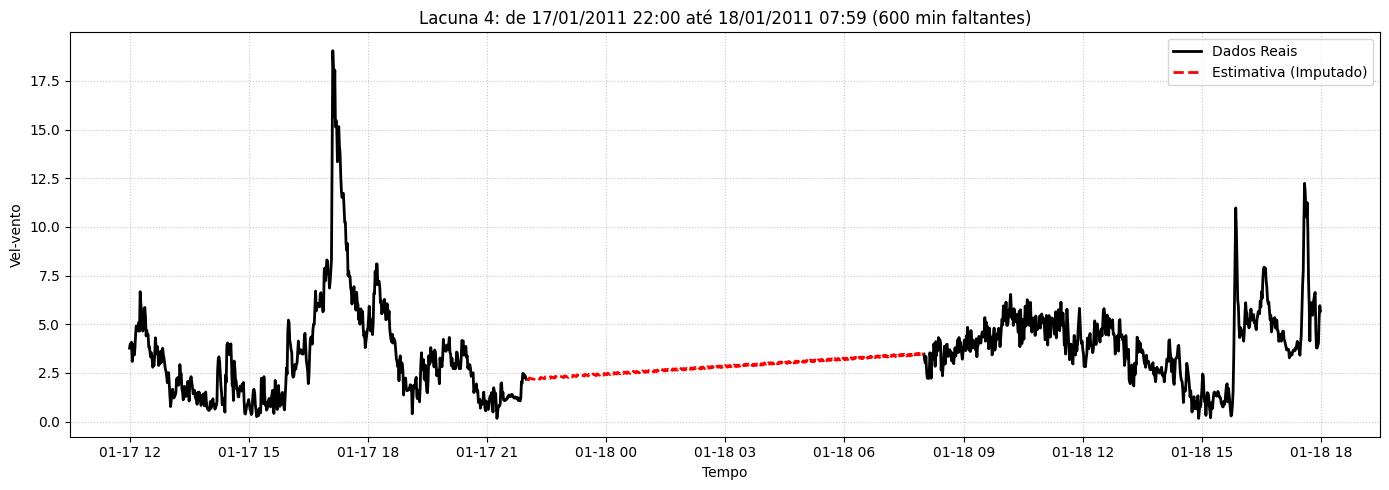

In [7]:
col_filled = f"{cfg.speed_column}_filled"

# 1. Criar uma máscara onde a coluna original estava nula
is_null = final_raw_data[cfg.speed_column].isnull()

# 2. Agrupar blocos contínuos de nulos/não-nulos
# Isso cria um ID único para cada sequência ininterrupta de NaNs
blocos = (is_null != is_null.shift()).cumsum()

# Filtrar apenas os IDs dos blocos que realmente representam falhas
blocos_nulos = blocos[is_null].unique()

print(f"Foram encontradas {len(blocos_nulos)} lacunas isoladas na série.")

plots_feitos = 0

for bloco_id in blocos_nulos:
    if plots_feitos >= 5:
        print(f"\n[!] Limite de {5} gráficos atingido. Aumente '5' se desejar ver as demais lacunas.")
        break
        
    # Pegar os índices do dataframe onde esse bloco específico de NaNs acontece
    idx_bloco = final_raw_data[blocos == bloco_id].index
    
    # Transformar os índices em posições numéricas inteiras para aplicar o "600" (margem)
    pos_start = final_raw_data.index.get_loc(idx_bloco[0])
    pos_end = final_raw_data.index.get_loc(idx_bloco[-1])
    
    # Definir limites do gráfico (garantindo que não vá buscar dados fora do tamanho do dataframe)
    plot_start = max(0, pos_start - 600)
    plot_end = min(len(final_raw_data) - 1, pos_end + 600)
    
    # Recortar o dataframe para a região do plot (Margem Real + Buraco Imputado + Margem Real)
    final_raw_data_plot = final_raw_data.iloc[plot_start : plot_end + 1]
    
    # 3. Gerar a visualização
    plt.figure(figsize=(14, 5))
    
    # Plot 1: Dados Originais (Preto) - Os NaNs naturalmente não aparecerão e deixarão o "buraco"
    plt.plot(
        final_raw_data_plot['data'], 
        final_raw_data_plot[cfg.speed_column], 
        color='black', 
        label='Dados Reais', 
        linewidth=2, 
        zorder=2
    )
    
    # Plot 2: Dados Imputados (Vermelho) - Pegamos apenas o pedaço exato do bloco para encaixar no buraco
    final_raw_data_imputado = final_raw_data.loc[idx_bloco]
    plt.plot(
        final_raw_data_imputado['data'], 
        final_raw_data_imputado[col_filled], 
        color='red', 
        label='Estimativa (Imputado)', 
        linewidth=2,
        linestyle='--',
        zorder=3
    )
    
    # Informações de texto para o título
    inicio_str = final_raw_data_imputado['data'].iloc[0].strftime('%d/%m/%Y %H:%M')
    fim_str = final_raw_data_imputado['data'].iloc[-1].strftime('%d/%m/%Y %H:%M')
    
    plt.title(f"Lacuna {plots_feitos + 1}: de {inicio_str} até {fim_str} ({len(idx_bloco)} min faltantes)", fontsize=12)
    plt.xlabel("Tempo", fontsize=10)
    plt.ylabel(cfg.speed_column, fontsize=10)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    plots_feitos += 1

# TESTES

In [13]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": -20.4328,
	"longitude": -51.3425,
	"start_date": "2010-10-01",
	"end_date": "2011-04-01",
	"hourly": ["temperature_2m", "relative_humidity_2m", "soil_temperature_0_to_7cm", "soil_temperature_7_to_28cm", "soil_temperature_28_to_100cm", "soil_temperature_100_to_255cm"],
	"timezone": "America/Sao_Paulo",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_soil_temperature_0_to_7cm = hourly.Variables(2).ValuesAsNumpy()
hourly_soil_temperature_7_to_28cm = hourly.Variables(3).ValuesAsNumpy()
hourly_soil_temperature_28_to_100cm = hourly.Variables(4).ValuesAsNumpy()
hourly_soil_temperature_100_to_255cm = hourly.Variables(5).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	).tz_convert(response.Timezone().decode())
}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["soil_temperature_0_to_7cm"] = hourly_soil_temperature_0_to_7cm
hourly_data["soil_temperature_7_to_28cm"] = hourly_soil_temperature_7_to_28cm
hourly_data["soil_temperature_28_to_100cm"] = hourly_soil_temperature_28_to_100cm
hourly_data["soil_temperature_100_to_255cm"] = hourly_soil_temperature_100_to_255cm

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)


Coordinates: -20.42179298400879°N -51.3380126953125°E
Elevation: 371.0 m asl
Timezone: b'America/Sao_Paulo'b'GMT-3'
Timezone difference to GMT+0: -10800s

Hourly data
                           date  temperature_2m  relative_humidity_2m  \
0    2010-10-01 00:00:00-03:00       24.130999             87.803436   
1    2010-10-01 01:00:00-03:00       24.380999             85.971069   
2    2010-10-01 02:00:00-03:00       23.380999             92.983673   
3    2010-10-01 03:00:00-03:00       23.630999             91.592613   
4    2010-10-01 04:00:00-03:00       24.130999             86.738167   
...                        ...             ...                   ...   
4387 2011-04-01 19:00:00-03:00       28.330999             65.436867   
4388 2011-04-01 20:00:00-03:00       27.730999             70.515564   
4389 2011-04-01 21:00:00-03:00       26.230999             81.345467   
4390 2011-04-01 22:00:00-03:00       25.880999             83.551971   
4391 2011-04-01 23:00:00-03:00       25.

In [18]:
hourly_dataframe['simplified_date'] = hourly_dataframe['date'].dt.strftime('%Y%m%d').astype(int)
hourly_dataframe["hour"] = hourly_dataframe['date'].dt.hour

In [19]:
hourly_dataframe.drop(columns= "date").to_excel("temperatura_open_meteo.xlsx", index= False)

In [36]:
hourly_dataframe[hourly_dataframe["simplified_date"] > 20101231].groupby("simplified_date").agg(
    temp_mean= ("temperature_2m", "mean"),
    temp_max= ("temperature_2m", "max"),
    temp_min= ("temperature_2m", "min"),
)

,temp_mean,temp_max,temp_min
simplified_date,,,
20110101,26.670584,29.931000,23.580999
20110102,25.931000,29.880999,23.580999
20110103,25.591415,29.230999,22.880999
20110104,25.483084,29.431000,22.880999
20110105,25.368500,28.880999,22.931000
...,...,...,...
20110328,25.664331,29.480999,22.480999
20110329,25.812250,28.931000,23.181000
20110330,26.268499,29.681000,23.181000
